# Interrupted Time Series Analysis (ITS)

## What is ITS?

**Interrupted Time Series (ITS)** is a quasi-experimental design used to evaluate the impact of an intervention by analyzing data collected at multiple time points before and after the intervention.

### Key Assumptions
- **Temporal ordering**: Data must be ordered in time
- **No concurrent interventions**: No other major changes at the same time point
- **Adequate pre-intervention data**: Typically ≥12 time points before the intervention
- **Stationarity or known trend**: The pre-intervention trend should be stable

### The Core Model

The standard segmented regression model is:

$$y_t = \\beta_0 + \\beta_1 \\cdot time_t + \\beta_2 \\cdot intervention_t + \\beta_3 \\cdot time\\_post_t + \\epsilon_t$$

| Parameter | Interpretation |
|-----------|---------------|
| $\\beta_0$ | Baseline level at time = 0 |
| $\\beta_1$ | Pre-intervention trend (slope) |
| $\\beta_2$ | **Level change** (immediate effect) |
| $\\beta_3$ | **Slope change** (trend difference post-intervention) |


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')

# ============================================
# Generate Synthetic ITS Data
# ============================================

np.random.seed(42)

n_pre = 24      # Pre-intervention periods
n_post = 12     # Post-intervention periods
n_total = n_pre + n_post
intervention_point = n_pre

time = np.arange(n_total)
noise = np.random.normal(0, 1.5, n_total)

# True data-generating process:
# Pre:  y = 10 + 0.5*t + noise
# Post: y = 10 + 0.5*t + 3.0 + 0.3*(t - intervention) + noise
y = np.zeros(n_total)
for i in range(n_total):
    if i < intervention_point:
        y[i] = 10 + 0.5 * time[i] + noise[i]
    else:
        y[i] = 10 + 0.5 * time[i] + 3.0 + 0.3 * (time[i] - intervention_point) + noise[i]

df = pd.DataFrame({
    'time': time,
    'y': y,
    'intervention': (time >= intervention_point).astype(int),
    'time_post': np.where(time >= intervention_point, time - intervention_point, 0)
})

print("Data shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print(f"\nIntervention occurs at time = {intervention_point}")


Data shape: (36, 4)

First 5 rows:
   time          y  intervention  time_post
0     0  10.745071             0          0
1     1  10.292604             0          0
2     2  11.971533             0          0
3     3  13.784545             0          0
4     4  11.648770             0          0

Intervention occurs at time = 24


## Raw Time Series Plot

This is the first and most important plot. It shows:
- The **pre-intervention trend** (baseline behavior)
- The **intervention point** (vertical line)
- The **post-intervention trend** (to visually inspect changes)

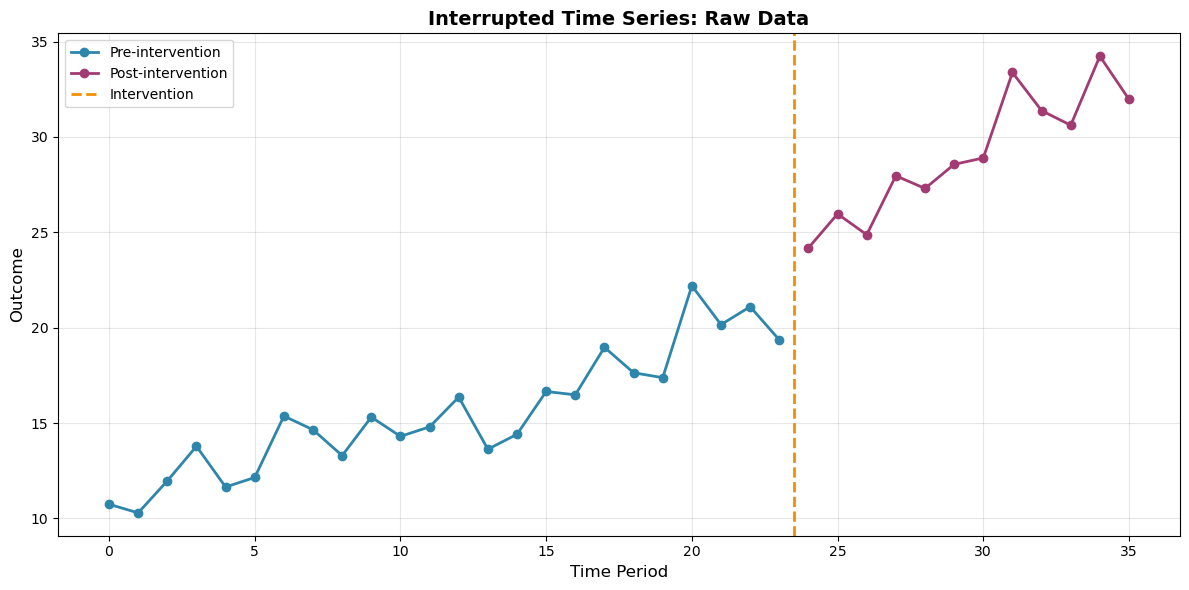

In [23]:
# ============================================
# Raw Time Series with Intervention Line
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

pre_mask = df['time'] < intervention_point
post_mask = df['time'] >= intervention_point

ax.plot(df.loc[pre_mask, 'time'], df.loc[pre_mask, 'y'],
        'o-', color='#2E86AB', linewidth=2, markersize=6, label='Pre-intervention')
ax.plot(df.loc[post_mask, 'time'], df.loc[post_mask, 'y'],
        'o-', color='#A23B72', linewidth=2, markersize=6, label='Post-intervention')

ax.axvline(x=intervention_point - 0.5, color='#F18F01', linestyle='--',
           linewidth=2, label='Intervention')

ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Outcome', fontsize=12)
ax.set_title('Interrupted Time Series: Raw Data', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 2: Segmented Regression with Counterfactual

This plot overlays:
- The **fitted segmented regression model**
- The **counterfactual** (what would have happened without the intervention)
- The **gap** between observed and counterfactual = the intervention effect

The counterfactual is computed by setting `intervention = 0` and `time_post = 0` for all time points.


Model Coefficients:
const           10.7494
time             0.4156
intervention     3.8506
time_post        0.4092
dtype: float64

P-values:
const           0.0000
time            0.0000
intervention    0.0003
time_post       0.0021
dtype: float64


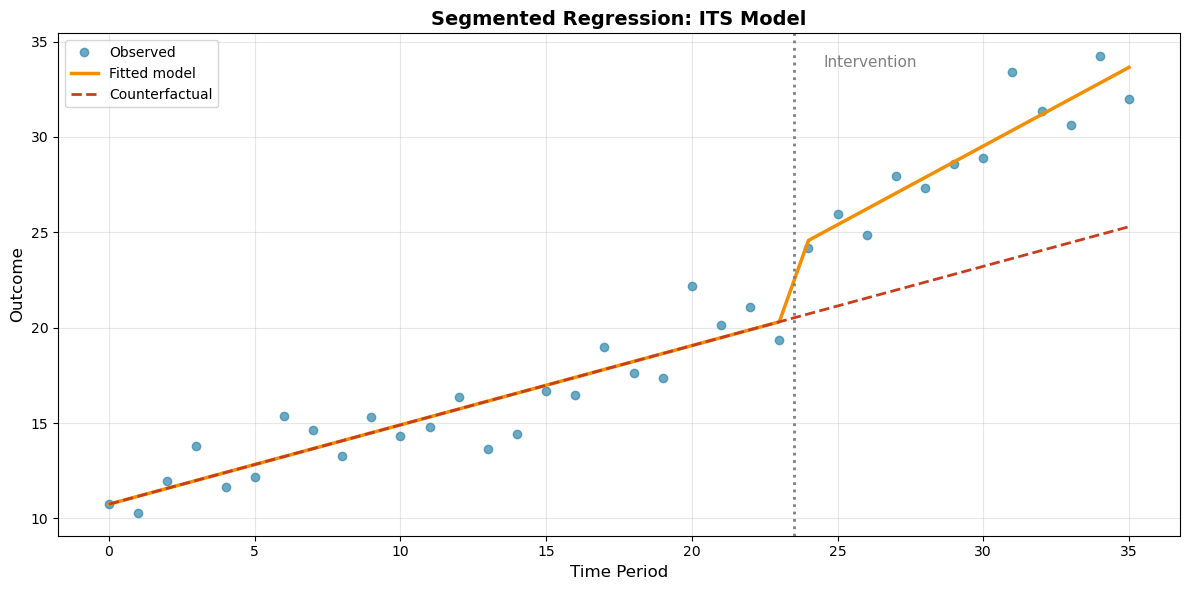

In [24]:
# ============================================
# Segmented Regression + Counterfactual
# ============================================

# Fit the ITS model
X = df[['time', 'intervention', 'time_post']].copy()
X = sm.add_constant(X)
model = sm.OLS(df['y'], X).fit()

print("Model Coefficients:")
print(model.params.round(4))
print("\nP-values:")
print(model.pvalues.round(4))

# Predictions
y_pred = model.predict(X)

# Counterfactual: set intervention and time_post to 0
X_counter = X.copy()
X_counter['intervention'] = 0
X_counter['time_post'] = 0
y_counter = model.predict(X_counter)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df['time'], df['y'], 'o', color='#2E86AB', markersize=6, alpha=0.7, label='Observed')
ax.plot(df['time'], y_pred, '-', color='#F18F01', linewidth=2.5, label='Fitted model')
ax.plot(df['time'], y_counter, '--', color='#C73E1D', linewidth=2, label='Counterfactual')

ax.axvline(x=intervention_point - 0.5, color='gray', linestyle=':', linewidth=2)
ax.text(intervention_point + 0.5, ax.get_ylim()[1] * 0.95, 'Intervention',
        fontsize=11, color='gray', ha='left')

ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Outcome', fontsize=12)
ax.set_title('Segmented Regression: ITS Model', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Residual Diagnostics

Residual analysis is critical in ITS because:
- **Autocorrelation** violates OLS assumptions (use Newey-West or ARIMA if severe)
- **Non-normality** affects inference validity
- **Heteroscedasticity** may indicate model misspecification

We check four diagnostic plots:
1. Residuals vs Time (look for patterns)
2. Residuals vs Fitted (check homoscedasticity)
3. Q-Q Plot (normality)
4. Histogram (distribution shape)

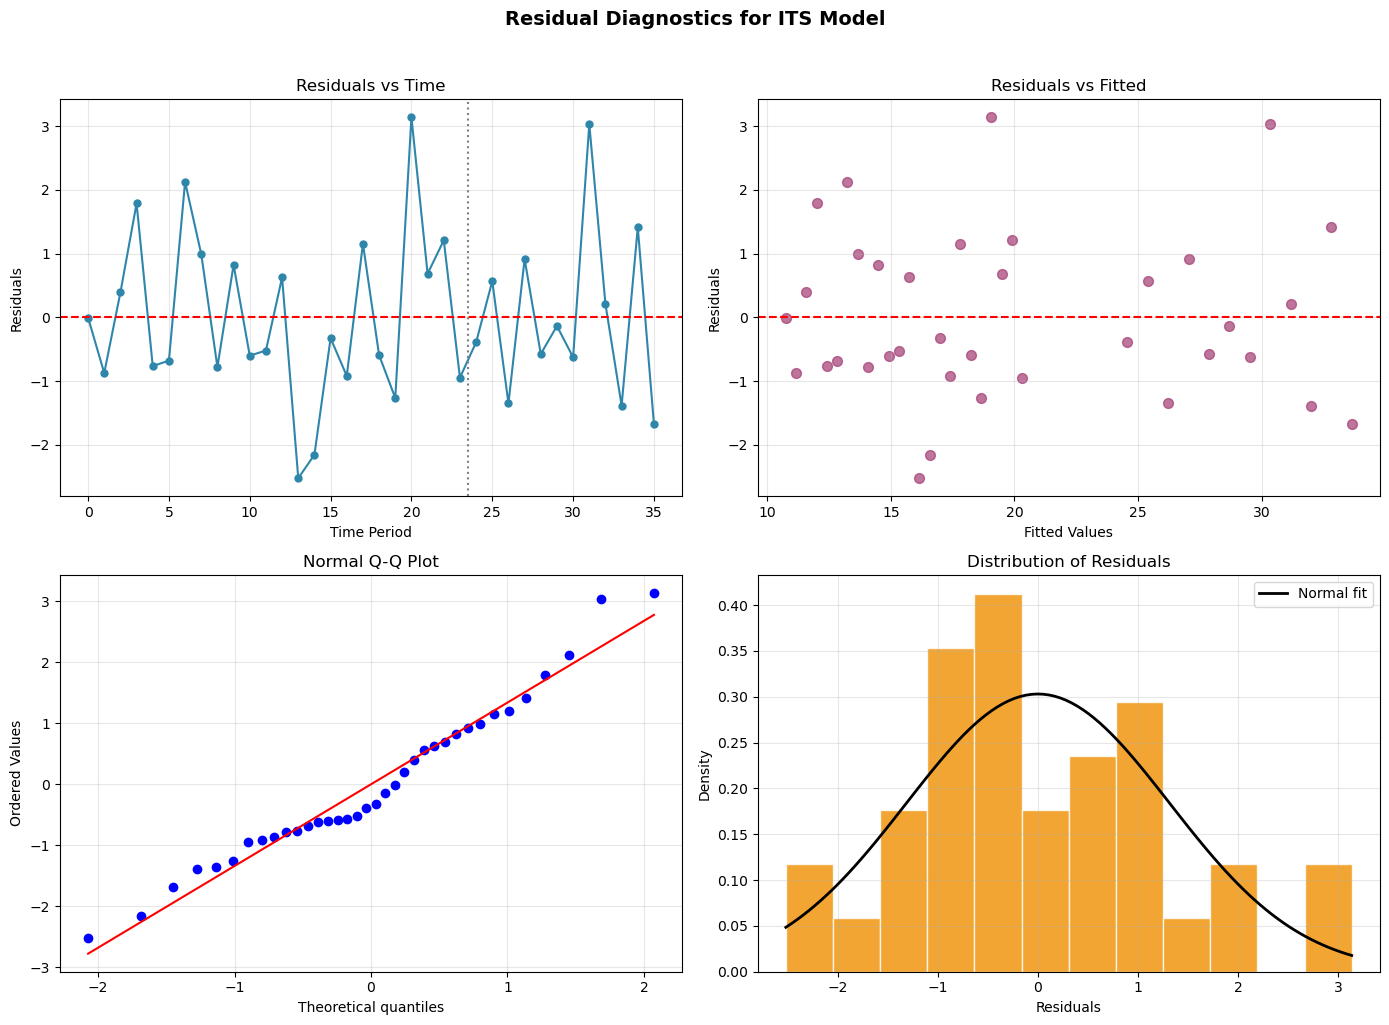


Durbin-Watson statistic: 2.221
(~2.0 = no autocorrelation, <1.5 or >2.5 suggests autocorrelation)


In [25]:
# ============================================
# Four-Panel Residual Diagnostics
# ============================================

residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Time
ax = axes[0, 0]
ax.plot(df['time'], residuals, 'o-', color='#2E86AB', markersize=5)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=intervention_point - 0.5, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Time Period')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Time')
ax.grid(True, alpha=0.3)

# 2. Residuals vs Fitted
ax = axes[0, 1]
ax.scatter(fitted, residuals, color='#A23B72', alpha=0.7, s=50)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted')
ax.grid(True, alpha=0.3)

# 3. Q-Q Plot
ax = axes[1, 0]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Normal Q-Q Plot')
ax.grid(True, alpha=0.3)

# 4. Histogram
ax = axes[1, 1]
ax.hist(residuals, bins=12, color='#F18F01', edgecolor='white', alpha=0.8, density=True)
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
        'k-', linewidth=2, label='Normal fit')
ax.set_xlabel('Residuals')
ax.set_ylabel('Density')
ax.set_title('Distribution of Residuals')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Residual Diagnostics for ITS Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print Durbin-Watson statistic
dw_stat = durbin_watson(residuals)
print(f"\nDurbin-Watson statistic: {dw_stat:.3f}")
print("(~2.0 = no autocorrelation, <1.5 or >2.5 suggests autocorrelation)")


## Autocorrelation Function (ACF)

The ACF of residuals reveals whether there is **serial correlation** in the errors. If bars exceed the confidence bounds (red dashed lines), autocorrelation is present and you should:

- Use **Newey-West standard errors** (HAC)
- Fit an **ARIMA-ITS** model instead of OLS
- Apply **Prais-Winsten transformation**

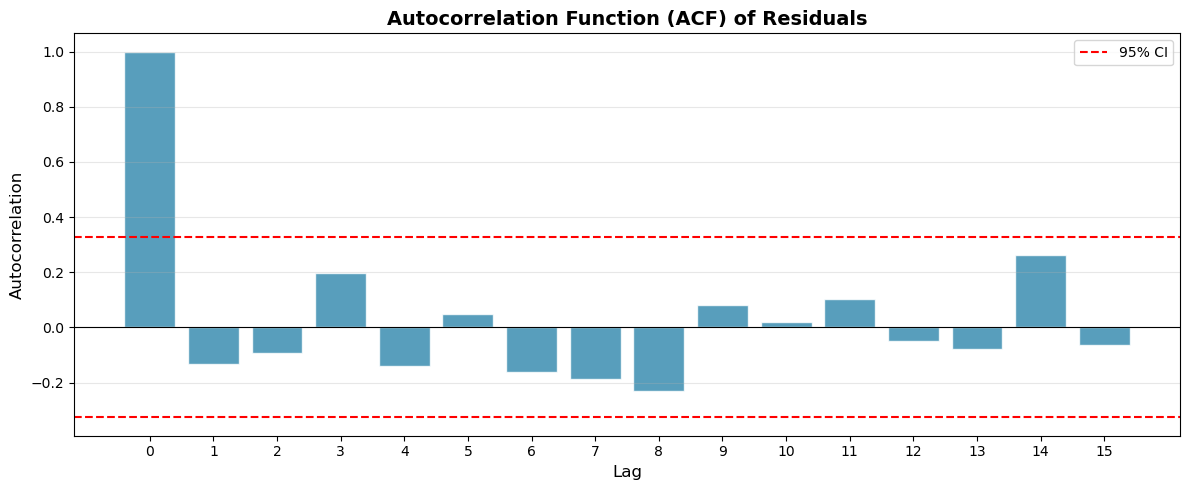

In [27]:
# ============================================
# Autocorrelation Function of Residuals
# ============================================

n_lags = min(15, len(residuals) // 2 - 1)
acf_vals, confint = acf(residuals, nlags=n_lags, alpha=0.05)

conf_upper = 1.96 / np.sqrt(len(residuals))
conf_lower = -1.96 / np.sqrt(len(residuals))

fig, ax = plt.subplots(figsize=(12, 5))

lags = np.arange(n_lags + 1)
ax.bar(lags, acf_vals, color='#2E86AB', edgecolor='white', alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axhline(y=conf_upper, color='red', linestyle='--', linewidth=1.5, label='95% CI')
ax.axhline(y=conf_lower, color='red', linestyle='--', linewidth=1.5)

ax.set_xlabel('Lag', fontsize=12)
ax.set_ylabel('Autocorrelation', fontsize=12)
ax.set_title('Autocorrelation Function (ACF) of Residuals', fontsize=14, fontweight='bold')
ax.set_xticks(lags)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## CUSUM & Effect Decomposition

**CUSUM (Cumulative Sum)** of residuals tests for structural breaks. If CUSUM crosses the red bounds, the model may be misspecified.

**Effect Decomposition** separates the intervention impact into:
- **Level change** ($\\beta_2$): Immediate jump at intervention
- **Trend change** ($\\beta_3$): Progressive divergence over time
- **Total effect**: Sum of both components at each post-intervention time point

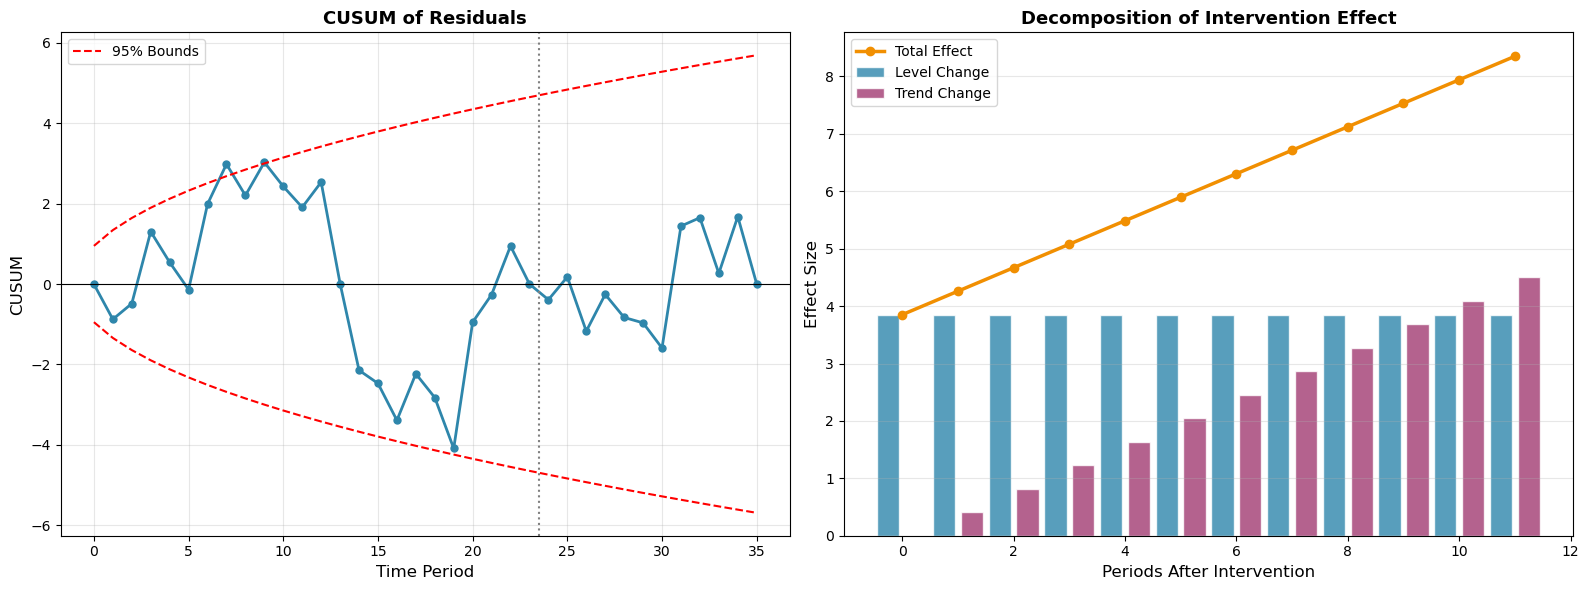

In [28]:
# ============================================
# CUSUM + Effect Decomposition
# ============================================

cusum = np.cumsum(residuals)
n_res = len(residuals)
cusum_upper = 0.948 * np.sqrt(n_res) * np.sqrt(np.arange(1, n_res + 1) / n_res)
cusum_lower = -cusum_upper

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: CUSUM ---
ax = axes[0]
ax.plot(df['time'], cusum, 'o-', color='#2E86AB', linewidth=2, markersize=5)
ax.plot(df['time'], cusum_upper, '--', color='red', linewidth=1.5, label='95% Bounds')
ax.plot(df['time'], cusum_lower, '--', color='red', linewidth=1.5)
ax.axvline(x=intervention_point - 0.5, color='gray', linestyle=':', linewidth=1.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('CUSUM', fontsize=12)
ax.set_title('CUSUM of Residuals', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Effect Decomposition ---
ax = axes[1]
time_post_range = np.arange(0, n_post)
level_effect = model.params['intervention'] * np.ones(n_post)
trend_effect = model.params['time_post'] * time_post_range
total_effect = level_effect + trend_effect

ax.bar(time_post_range - 0.25, level_effect, width=0.4, color='#2E86AB',
       label='Level Change', alpha=0.8, edgecolor='white')
ax.bar(time_post_range + 0.25, trend_effect, width=0.4, color='#A23B72',
       label='Trend Change', alpha=0.8, edgecolor='white')
ax.plot(time_post_range, total_effect, 'o-', color='#F18F01', linewidth=2.5,
        markersize=6, label='Total Effect')

ax.set_xlabel('Periods After Intervention', fontsize=12)
ax.set_ylabel('Effect Size', fontsize=12)
ax.set_title('Decomposition of Intervention Effect', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Confidence Intervals & Effect Zone

This plot shows:
- **95% confidence intervals** around the fitted model
- **Counterfactual confidence band** (shaded red)
- **Effect Zone** (green shaded area): The cumulative gap between observed and counterfactual

The area of the effect zone can be computed using `np.trapezoid` to quantify the total impact.


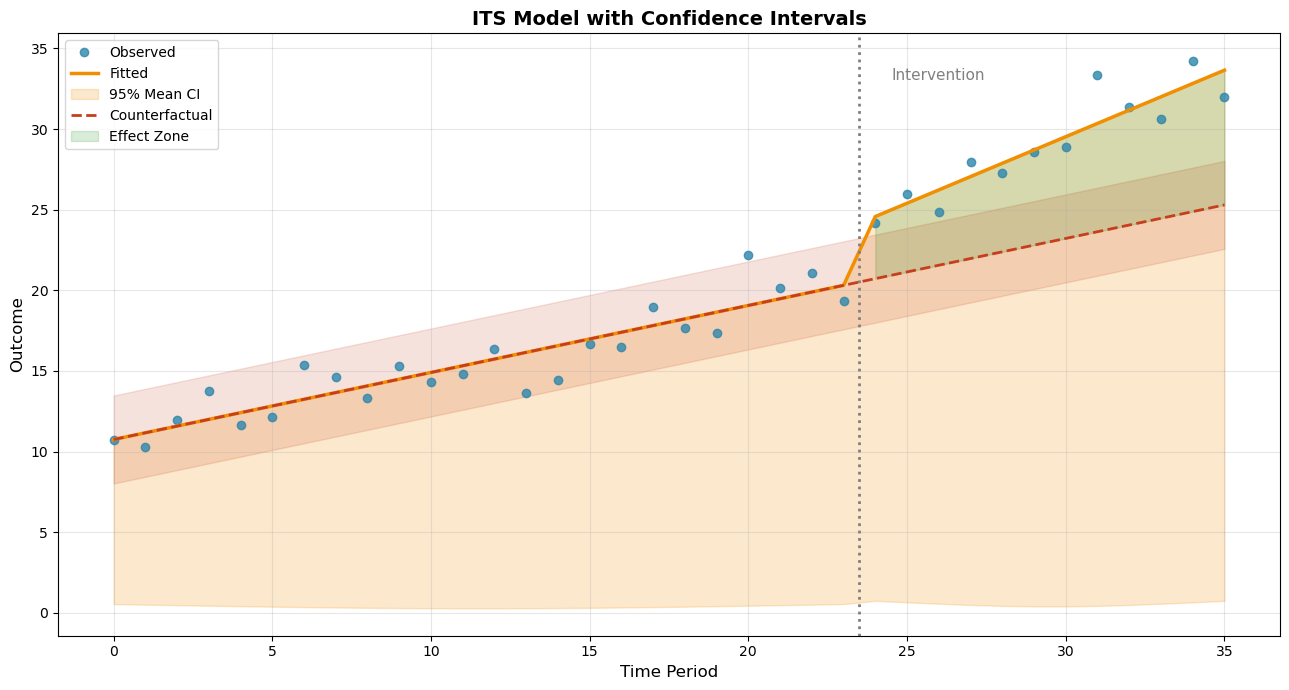


Total effect area (np.trapezoid): 67.111
This represents the cumulative deviation from counterfactual.


In [29]:
# ============================================
# Model with CIs + Effect Zone
# ============================================

from statsmodels.stats.outliers_influence import summary_table

# Mean CI for fitted model
st, data, ss2 = summary_table(model, alpha=0.05)
mean_ci_low, mean_ci_upp = data[:, 2:4].T

# Counterfactual from pre-intervention model
pre_model = sm.OLS(df.loc[pre_mask, 'y'],
                   sm.add_constant(df.loc[pre_mask, 'time'])).fit()
counter_pred = pre_model.predict(sm.add_constant(df['time']))

# Approximate counterfactual CI
pre_se = np.sqrt(pre_model.mse_resid)
counter_ci_low = counter_pred - 1.96 * pre_se * np.sqrt(1 + 1/n_pre)
counter_ci_upp = counter_pred + 1.96 * pre_se * np.sqrt(1 + 1/n_pre)

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(df['time'], df['y'], 'o', color='#2E86AB', markersize=6, alpha=0.8, label='Observed')
ax.plot(df['time'], y_pred, '-', color='#F18F01', linewidth=2.5, label='Fitted')
ax.fill_between(df['time'], mean_ci_low, mean_ci_upp, color='#F18F01', alpha=0.2, label='95% Mean CI')

ax.plot(df['time'], counter_pred, '--', color='#C73E1D', linewidth=2, label='Counterfactual')
ax.fill_between(df['time'], counter_ci_low, counter_ci_upp, color='#C73E1D', alpha=0.15)

ax.axvline(x=intervention_point - 0.5, color='gray', linestyle=':', linewidth=2)
ax.text(intervention_point + 0.5, ax.get_ylim()[1] * 0.92, 'Intervention',
        fontsize=11, color='gray', ha='left')

# Shade the effect area (post-intervention only)
post_times = df.loc[post_mask, 'time']
ax.fill_between(post_times, y_pred[post_mask], counter_pred[post_mask],
                color='green', alpha=0.15, label='Effect Zone')

ax.set_xlabel('Time Period', fontsize=12)
ax.set_ylabel('Outcome', fontsize=12)
ax.set_title('ITS Model with Confidence Intervals', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute total effect area using np.trapezoid
effect_area = np.trapezoid(y_pred[post_mask] - counter_pred[post_mask],
                            x=post_times.values)
print(f"\nTotal effect area (np.trapezoid): {effect_area:.3f}")
print("This represents the cumulative deviation from counterfactual.")


## Summary: How to Interpret Results

| Finding | Interpretation |
|---------|---------------|
| $\\beta_2$ significant | There is an **immediate level change** |
| $\\beta_3$ significant | The **trend changed** after intervention |
| Both significant | Intervention had both immediate and growing effects |
| Neither significant | No detectable intervention effect |
| DW < 1.5 or > 2.5 | Use HAC/ARIMA to correct autocorrelation |
| CUSUM crosses bounds | Model may be misspecified; check for other breakpoints |

## Next Steps for Real Data

1. **Check for seasonality**: Add seasonal dummy variables or use seasonal ARIMA
2. **Control for confounders**: Include covariates if available
3. **Sensitivity analysis**: Test different model specifications
4. **Reporting**: Follow RAMSEY or EPOC guidelines for ITS studies

In [30]:
# ============================================
# Final Summary Table
# ============================================

summary_data = {
    'Parameter': ['Intercept (beta_0)', 'Pre-trend (beta_1)', 
                  'Level change (beta_2)', 'Slope change (beta_3)'],
    'Estimate': [model.params['const'], model.params['time'],
                 model.params['intervention'], model.params['time_post']],
    'Std Error': [model.bse['const'], model.bse['time'],
                  model.bse['intervention'], model.bse['time_post']],
    'P-value': [model.pvalues['const'], model.pvalues['time'],
                model.pvalues['intervention'], model.pvalues['time_post']]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Significant'] = summary_df['P-value'].apply(lambda p: 'Yes' if p < 0.05 else 'No')

print("=" * 65)
print("INTERRUPTED TIME SERIES ANALYSIS: SUMMARY")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

# Effect at specific time points
print("\nPredicted effect at key post-intervention time points:")
for t_post in [0, 5, 11]:
    t_abs = intervention_point + t_post
    effect = (model.params['intervention'] + 
              model.params['time_post'] * t_post)
    print(f"  Time {t_abs} ({t_post} periods post): Effect = {effect:.3f}")


INTERRUPTED TIME SERIES ANALYSIS: SUMMARY
            Parameter  Estimate  Std Error      P-value Significant
   Intercept (beta_0) 10.749358   0.545144 1.815712e-19         Yes
   Pre-trend (beta_1)  0.415581   0.040614 1.288097e-11         Yes
Level change (beta_2)  3.850556   0.946633 2.895080e-04         Yes
Slope change (beta_3)  0.409170   0.122125 2.081001e-03         Yes

Predicted effect at key post-intervention time points:
  Time 24 (0 periods post): Effect = 3.851
  Time 29 (5 periods post): Effect = 5.896
  Time 35 (11 periods post): Effect = 8.351
